In [1]:
import matplotlib.pyplot as plt
import netCDF4
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import glasbey
from matplotlib.colors import ListedColormap
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

# Change working directory
import os
os.chdir(os.getcwd() + "/../")

import config
from uncertainty_experiments.uncertainty_metrics import compute_uncertainty_metrics
from visualisation.plotting import plot_sankey

# Ecological Marine Units

Downloaded "EMU netCDF" file from https://esri.maps.arcgis.com/home/group.html?id=6c78a5125d3244f38d1bc732ef0ee743#overview

In [2]:
fp = "../../data/province_shapes/emu_netCDF/emu_v5_20200914.nc"
nc = netCDF4.Dataset(fp)

In [3]:
lat = nc.variables["latitude"][:]
lon = nc.variables["longitude"][:]
depth = nc.variables["depth"][:] * -1

temp = nc.variables["temp"][:]
salinity = nc.variables["salinity"][:]
appO2ut = nc.variables["appO2ut"][:]
dissO2 = nc.variables["dissO2"][:]
nitrate = nc.variables["nitrate"][:]
percO2sat = nc.variables["percO2sat"][:]
phosphate = nc.variables["phosphate"][:]
silicate = nc.variables["silicate"][:]
srtm30 = nc.variables["srtm30"][:]

emu = nc.variables["name_emu"][:]

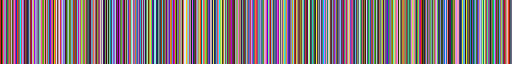

In [4]:
# Define color map and ranges
unique_labels = np.sort(np.unique(emu.data))
upper = unique_labels.max() if not np.isnan(unique_labels.max()) else unique_labels[-2]
lower = unique_labels[0]

colors = glasbey.create_palette(palette_size=abs(upper-lower))
cm = ListedColormap(colors)  

vmin = emu.min() 
vmax = emu.max()

cm

interactive(children=(IntSlider(value=101, description='depth_level', max=101), Output()), _dom_classes=('widg…

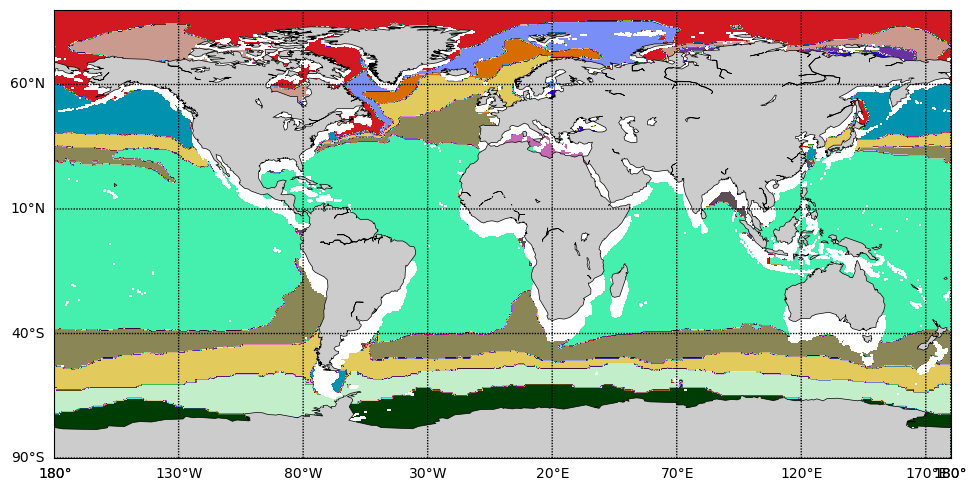

In [5]:
lon_min = -180
lon_max = 180

lat_min = -90
lat_max = 90

# Plot global regions
plt.rcParams["figure.figsize"] = (10, 5)

# Plot settings
factor = 12
mymap_glob = Basemap(llcrnrlon=lon_min, llcrnrlat=lat_min, urcrnrlon=lon_max, urcrnrlat=lat_max)

def plot_emus_over_depth(depth_level):
    plt.imshow(np.flipud(emu[depth_level,:,:]), cmap=cm, vmin=vmin, vmax=vmax, extent=[lon_min, lon_max, lat_min, lat_max])
    mymap_glob.drawcoastlines(linewidth=0.5)
    mymap_glob.fillcontinents()
    mymap_glob.drawparallels(np.arange(int(lat_min),int(lat_max), 50),labels=[1,0,0,0])
    mymap_glob.drawmeridians(np.arange(int(lon_min),int(lon_max), 50),labels=[0,0,0,1])
    plt.tight_layout()

depth_levels = np.array((range(len(depth))))
interact(plot_emus_over_depth, depth_level=widgets.IntSlider(value=depth_levels.max(), min=depth_levels.min(), max=depth_levels.max(), step=1))

plt.show()

## North Atlantic 
(esp. deep waters)

interactive(children=(IntSlider(value=101, description='depth_level', max=101), Output()), _dom_classes=('widg…

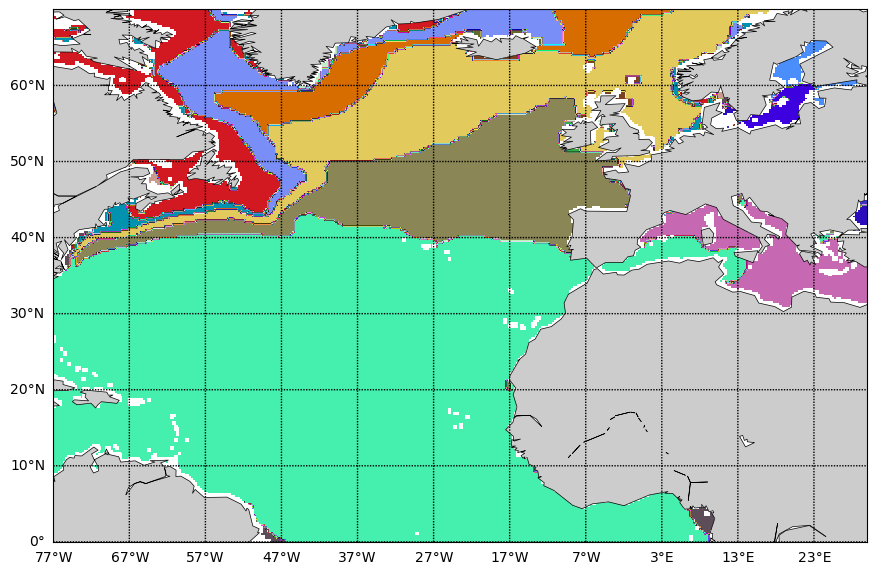

In [6]:
# Defining our area of interest
lat_min = config.grid_config["lat_min"]
lat_max = config.grid_config["lat_max"]

lon_min = config.grid_config["lon_min"]
lon_max = config.grid_config["lon_max"]

# Latitude lower and upper index
lat_min_p = np.argmin( np.abs( lat - lat_min ) )
lat_max_p = np.argmin( np.abs( lat - lat_max ) ) 

# Longitude lower and upper index
lon_min_p = np.argmin( np.abs( lon - lon_min ) )
lon_max_p = np.argmin( np.abs( lon - lon_max ) )  

our_emu = emu[:, lat_min_p:lat_max_p, lon_min_p:lon_max_p]

# Plot settings
factor = 12
mymap = Basemap(llcrnrlon=lon_min, llcrnrlat=lat_min, urcrnrlon=lon_max, urcrnrlat=lat_max)
plt.rcParams["figure.figsize"] = ((lon_max - lon_min)/factor, (lat_max - lat_min)/factor)

# Plot
def plot_emus_over_depth_na(depth_level):
    t = our_emu[depth_level,:,:]
    mymap.imshow(t, cmap=cm, vmin=vmin, vmax=vmax)
    mymap.drawcoastlines(linewidth=0.5)
    mymap.fillcontinents()
    mymap.drawparallels(np.arange(int(lat_min),int(lat_max), 10),labels=[1,0,0,0])
    mymap.drawmeridians(np.arange(int(lon_min),int(lon_max), 10),labels=[0,0,0,1])
    plt.tight_layout()
    # plt.savefig(f"{config.output_dir_plots}emu_{depth_level}.png")
    plt.savefig(f"{config.output_dir_plots_high_res}emu_{depth_level}.png", dpi=1000)

depth_levels = np.array((range(len(depth))))
interact(plot_emus_over_depth_na, depth_level=widgets.IntSlider(value=depth_levels.max(), min=depth_levels.min(), max=depth_levels.max(), step=1))

plt.show()

In [7]:
print(f"Our Atlantic deep water regions are equivalent to depth levels 0 until {np.argwhere(depth==3000)[0][0]} of the EMU regions.")

Our Atlantic deep water regions are equivalent to depth levels 0 until 25 of the EMU regions.


## Labrador Sea

interactive(children=(IntSlider(value=101, description='depth_level', max=101), Output()), _dom_classes=('widg…

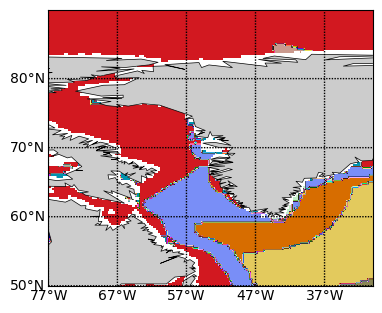

In [8]:
lon_min = -77
lon_max = -30 

lat_min = 50
lat_max = 90

# Latitude lower and upper index
lat_min_p = np.argmin( np.abs( lat - lat_min ) )
lat_max_p = np.argmin( np.abs( lat - lat_max ) ) 

# Longitude lower and upper index
lon_min_p = np.argmin( np.abs( lon - lon_min ) )
lon_max_p = np.argmin( np.abs( lon - lon_max ) )  

lab_emu = emu[:, lat_min_p:lat_max_p, lon_min_p:lon_max_p]

factor = 12
plt.rcParams["figure.figsize"] = ((lon_max - lon_min)/factor, (lat_max - lat_min)/factor)
mymap_lab = Basemap(llcrnrlon=lon_min, llcrnrlat=lat_min, urcrnrlon=lon_max, urcrnrlat=lat_max)

def plot_emus_over_depth_lab(depth_level):
    t = lab_emu[depth_level,:,:]
    plt.imshow(np.flipud(t), cmap=cm, vmin=vmin, vmax=vmax, extent=[lon_min, lon_max, lat_min, lat_max])
    mymap_lab.drawcoastlines(linewidth=0.5)
    mymap_lab.fillcontinents()
    mymap_lab.drawparallels(np.arange(int(lat_min),int(lat_max), 10),labels=[1,0,0,0])
    mymap_lab.drawmeridians(np.arange(int(lon_min),int(lon_max), 10),labels=[0,0,0,1])
    plt.tight_layout()

depth_levels = np.array((range(len(depth))))
interact(plot_emus_over_depth_lab, depth_level=widgets.IntSlider(value=depth_levels.max(), min=depth_levels.min(), max=depth_levels.max(), step=1))

plt.show()

## Mediterranean Sea

interactive(children=(IntSlider(value=101, description='depth_level', max=101), Output()), _dom_classes=('widg…

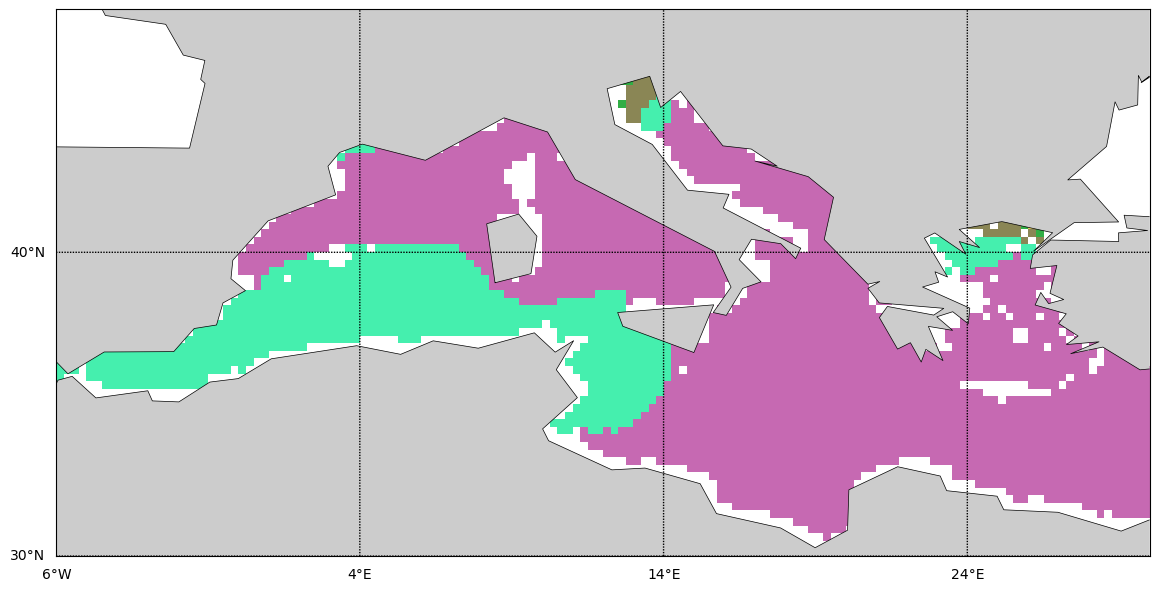

In [9]:
lon_min = -6
lon_max = 30

lat_min = 30
lat_max = 48

# Latitude lower and upper index
lat_min_p = np.argmin( np.abs( lat - lat_min ) )
lat_max_p = np.argmin( np.abs( lat - lat_max ) ) 

# Longitude lower and upper index
lon_min_p = np.argmin( np.abs( lon - lon_min ) )
lon_max_p = np.argmin( np.abs( lon - lon_max ) )  

# Define Mediterranean area
medi_emu = emu[:, lat_min_p:lat_max_p , lon_min_p:lon_max_p]
for loni in range(medi_emu.shape[2]):
    for lati in range(medi_emu.shape[1]):
        if (lati > 50 and loni < 35) or (lati > 40 and loni > 130):
            medi_emu.mask[:, lati, loni] = True 
            medi_emu.data[:, lati, loni] = -9999
medi_labels = np.delete(np.sort(np.unique(medi_emu.data)), 0)

# Plot settings
factor = 12
plt.rcParams["figure.figsize"] = ((lon_max - lon_min)/factor, (lat_max - lat_min)/factor)
mymap_med = Basemap(llcrnrlon=lon_min, llcrnrlat=lat_min, urcrnrlon=lon_max, urcrnrlat=lat_max)

def plot_emus_over_depth_med(depth_level):
    plt.imshow(np.flipud(medi_emu[depth_level,:,:]), cmap=cm, vmin=vmin, vmax=vmax, extent=[lon_min, lon_max, lat_min, lat_max])
    mymap_med.drawcoastlines(linewidth=0.5)
    mymap_med.fillcontinents()
    mymap_med.drawparallels(np.arange(int(lat_min),int(lat_max), 10),labels=[1,0,0,0])
    mymap_med.drawmeridians(np.arange(int(lon_min),int(lon_max), 10),labels=[0,0,0,1])
    plt.tight_layout()

plt.rcParams["figure.figsize"] = (abs((lon_max_p-lon_min_p)/12), abs((lat_max_p-lat_min_p)/12))
depth_levels = np.array((range(len(depth))))
interact(plot_emus_over_depth_med, depth_level=widgets.IntSlider(value=depth_levels.max(), min=depth_levels.min(), max=depth_levels.max(), step=1))

plt.show()

In [10]:
print(f"Cluster vanish below {depth[80]} m.")

Cluster vanish below 125 m.


# Compute overlap scores

In [7]:
# Load our regions
df = pd.read_csv(f"{config.output_dir}cluster_set.csv")
df[["LATITUDE", "LONGITUDE", "LEV_M"]] = df[["LATITUDE", "LONGITUDE", "LEV_M"]].round(2)

# Store EMUs as df
zz, yy, xx = np.meshgrid(depth, lat, lon, indexing='ij') 
df_emu = pd.DataFrame({"LATITUDE": yy.ravel(), "LONGITUDE": xx.ravel(), "LEV_M": zz.ravel(), "emu_label": emu.ravel()}).dropna()

In [8]:
# Mapping EMU data to our grid cells
# Map latitude
lat_bins = np.arange(config.grid_config["lat_min"], config.grid_config["lat_max"] + config.grid_config["dlat"], config.grid_config["dlat"]).astype(float)
lat_bins[-1] = lat_bins[-1] + 0.001 * (1 if lat_bins[-1] >= 0 else -1)
df_emu["LATITUDE"] = pd.cut(df_emu["LATITUDE"], bins=lat_bins, right=False, labels=lat_bins[:-1] + config.grid_config["dlat"] / 2)

# Map longitude
lon_bins = np.arange(config.grid_config["lon_min"], config.grid_config["lon_max"] + config.grid_config["dlon"], config.grid_config["dlon"]).astype(float)
lon_bins[-1] = lon_bins[-1] + 0.001 * (1 if lon_bins[-1] >= 0 else -1)
df_emu["LONGITUDE"] = pd.cut(df_emu["LONGITUDE"], bins=lon_bins, right=False, labels=lon_bins[:-1] + config.grid_config["dlon"] / 2)

# Map depth
z_bins = np.sort(df["LEV_M"].unique())
z_bins[-1] = z_bins[-1] + 0.001  # make sure, last values are included while cutting using pandas
df_emu["LEV_M"] = pd.cut(df_emu["LEV_M"], bins=z_bins, right=False, labels=z_bins[:-1])

In [9]:
# Drop cells that have no label
df_emu = df_emu.dropna()

# Majority vote to determine EMU label of a grid cell
majority_labels = (df_emu.groupby(["LATITUDE", "LONGITUDE", "LEV_M"], observed=True)["emu_label"].agg(lambda x: x.value_counts().idxmax()).reset_index())
majority_labels[["LATITUDE", "LONGITUDE", "LEV_M"]] = majority_labels[["LATITUDE", "LONGITUDE", "LEV_M"]].astype(np.float32).round(2)
majority_labels[["emu_label"]] = majority_labels[["emu_label"]].astype(int)

# Merge with our dataframe (and drop NaNs)
df_merged = df.merge(majority_labels, how="left", on=["LATITUDE", "LONGITUDE", "LEV_M"]).dropna()

In [10]:
# Compute overlap metrics between the two cluster sets (our surface and Longhurst)
clustering_a = df_merged[["LATITUDE", "LONGITUDE", "LEV_M", "label"]].copy()
clustering_b = df_merged[["LATITUDE", "LONGITUDE", "LEV_M", "emu_label"]].copy()
compute_uncertainty_metrics(clustering_a, clustering_b, label_a="label", label_b="emu_label")

,overlap_ab,overlap_ba,overlap,f_accuracy_ab,f_accuracy_ba,f_accuracy,mutual_information,variation_of_information,normalized_mutual_information,adjusted_rand_score
0,0.862977,0.373669,0.618323,0.338405,0.477382,0.407893,1.460076,2.838803,0.507063,0.178866


Quantitative comparisons between the clustering and EMU labels indicate moderate structural and informational alignment, with an Adjusted Rand Index of 0.179 and a Normalized Mutual Information score of 0.507. These suggest that while both classifications capture some common features, the new clustering reflects a distinct organization of water masses. Despite these differences, a high weighted overlay accuracy of 0.863 reveals strong spatial coherence, indicating that the two systems agree on dominant patterns across most of the domain.


We also compared our clusters with the Ecological Marine Units (EMUs) to evaluate spatial and structural correspondence. The analysis revealed a high degree of spatial overlap from our clusters onto the EMUs (overlap_ab = 86.3%), though the reverse was less pronounced (overlap_ba = 37.4%), suggesting our clusters broadly encompass EMU-defined regions. Structural similarity was modest, with a normalized mutual information (NMI) of 0.51 and an adjusted Rand index (ARI) of 0.18, both slightly higher than those observed in the comparison with Longhurst provinces. These findings indicate a somewhat stronger alignment with EMUs, possibly reflecting a closer methodological or environmental basis for similarity, though key differences in clustering structure remain.

In [15]:
# Sankey plot
s = plot_sankey(df_merged, source_col="label", target_col="emu_label", color_col="uncertainty", color_palette="Oranges_9", figsize_px=(827*2, 1169*2), save_as=f"{config.output_dir_plots_high_res}/sankey_emus.png")

# Save as SVG (convert to PDF externally)
s.auto_save_svg(f"{config.output_dir_plots_high_res}/sankey_emus.svg")

SankeyWidget(groups=[{'id': 'Labels', 'type': 'process', 'title': '', 'nodes': ['Labels^0', 'Labels^1', 'Label…